In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [2]:
df = pd.DataFrame({
    'Temperature' : [1, 2, 3, 4, 5, 6, 7, 8,],
    'Energy Consumption' : [2, 5, 9, 15, 14, 10, 5, 1]
})

<Axes: xlabel='Temperature', ylabel='Energy Consumption'>

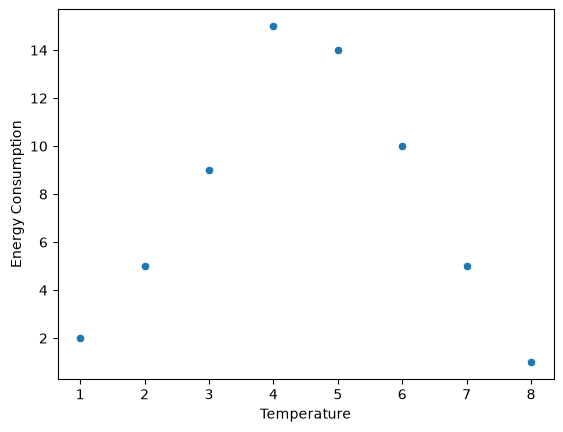

In [3]:
sns.scatterplot(data=df, x='Temperature', y='Energy Consumption')

In [4]:
x = df[['Temperature']]
y = df['Energy Consumption']

x_poly = PolynomialFeatures(degree=2).fit_transform(x)
print(x_poly)

[[ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]
 [ 1.  4. 16.]
 [ 1.  5. 25.]
 [ 1.  6. 36.]
 [ 1.  7. 49.]
 [ 1.  8. 64.]]


In [5]:
model = LinearRegression().fit(x_poly, y)
print(model.intercept_)
print(model.coef_)

# for value 2.
#energy_consumption_prediction = model,prediction([1,2,4])

# more better way

energy_consumption_prediction = model.predict(PolynomialFeatures(degree=2).fit_transform([[2]]))
print(f"energy consumption prediction: {energy_consumption_prediction}")

-7.374999999999908
[ 0.          9.10119048 -1.01785714]
energy consumption prediction: [6.75595238]


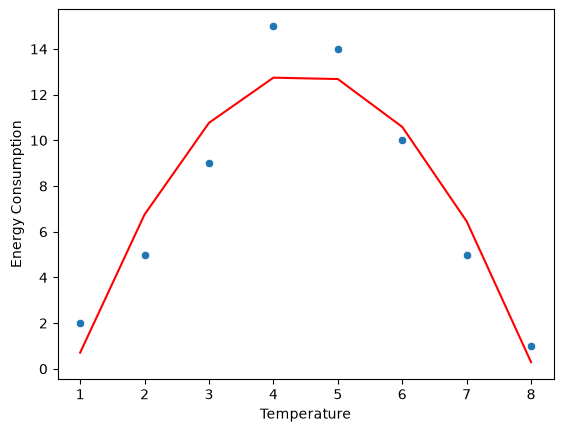

In [6]:
predicted_existing = model.predict(x_poly)

sns.scatterplot(data=df, x='Temperature', y='Energy Consumption')
plt.plot(x,predicted_existing, color='red')

In [11]:
y_predicted = model.predict(x_poly)

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

accuracy = r2_score(y,y_predicted)

print(" R2 accuracy is: "+str(accuracy))

 R2 accuracy is: 0.9078951450286955
